# EDA

In [8]:
import bvhio

bvh_path = "../data/002/02_01.bvh"
root = bvhio.readAsHierarchy(bvh_path)

# inspect skeleton structure
root.printTree()

Hips
+- LHipJoint
|  +- LeftUpLeg
|     +- LeftLeg
|        +- LeftFoot
|           +- LeftToeBase
+- RHipJoint
|  +- RightUpLeg
|     +- RightLeg
|        +- RightFoot
|           +- RightToeBase
+- LowerBack
   +- Spine
      +- Spine1
         +- Neck
         |  +- Neck1
         |     +- Head
         +- LeftShoulder
         |  +- LeftArm
         |     +- LeftForeArm
         |        +- LeftHand
         |           +- LeftFingerBase
         |           |  +- LeftHandIndex1
         |           +- LThumb
         +- RightShoulder
            +- RightArm
               +- RightForeArm
                  +- RightHand
                     +- RightFingerBase
                     |  +- RightHandIndex1
                     +- RThumb


(2646, 15, 3)
[[10.07734    -0.71228284 25.092813  ]
 [10.04305    -0.7486024  23.529621  ]
 [10.0061     -0.2602     17.8631    ]
 [ 6.5379     -0.78669    22.741901  ]
 [ 1.560327   -0.7866899  22.042349  ]
 [-1.7712419  -0.7866898  21.574127  ]
 [13.57797    -0.63416994 22.88632   ]
 [18.395754   -0.63417    22.209225  ]
 [21.71864    -0.63417    21.742224  ]
 [ 8.395399    0.36456007 16.06028   ]
 [ 8.52782     0.36456034  8.474094  ]
 [ 8.653749    0.3645609   1.2598143 ]
 [11.662839    0.36456957 16.06028   ]
 [11.530308    0.36456957  8.467721  ]
 [11.4031315   0.3645696   1.1816587 ]]
[[ 9.834528   -0.30629465 25.122751  ]
 [10.038015   -0.6505515  23.61075   ]
 [10.3115     -0.9184     17.9339    ]
 [ 6.7753687  -2.0733066  22.653486  ]
 [ 5.769721   -3.749146   18.02252   ]
 [ 6.3711457  -0.8496785  16.425657  ]
 [13.368792    0.35298777 23.150045  ]
 [13.562537   -0.52068573 18.367926  ]
 [13.613763    0.71994656 15.250577  ]
 [ 8.581893   -0.6830907  16.148422  ]
 [ 8.24132

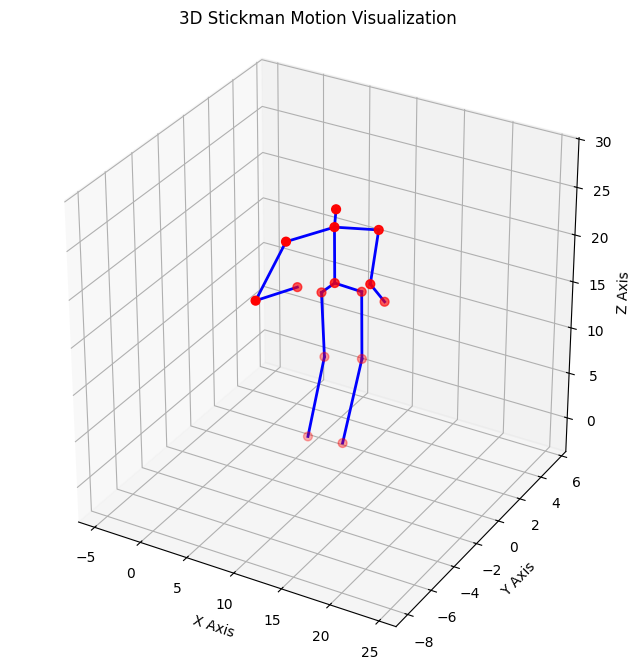

In [10]:
import sys
sys.path.append("..")

import importlib
import data_loader, utils
importlib.reload(data_loader)
importlib.reload(utils)

from data_loader import load_bvh_as_tensor
from utils import animate_skeleton_3d

tensor = load_bvh_as_tensor("../data/002/02_10.bvh")
print(tensor.shape)       
print(tensor[0])         
print(tensor[50])         

anim = animate_skeleton_3d(tensor[:48], output_filename="test_gifs/test_walk.gif")

In [16]:
import pandas as pd

df = pd.read_excel("../cmu-mocap-index-spreadsheet.xls", header=None, skiprows=7)
df.columns = ["motion_id", "description", "subject"]
df = df.dropna(subset=["motion_id"])

walk_files = df[df["description"].str.contains("walk", case=False, na=False)]
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
print(walk_files[["motion_id", "description"]].to_string())
print("Walk files found:", len(walk_files))

     motion_id                                                                                                           description
20       02_01                                                                                                                  walk
21       02_02                                                                                                                  walk
31       03_01                                                                                                walk on uneven terrain
32       03_02                                                                                                walk on uneven terrain
33       03_03                                                                                                walk on uneven terrain
34       03_04                                                                                                walk on uneven terrain
36       05_01                                                       

In [17]:
clean_walk_keywords = ["^walk$", "^walk forward$", "^slow walk$", "^brisk walk$", "^normal walk$"]
pattern = "|".join(clean_walk_keywords)

clean_walk = df[df["description"].str.match(pattern, case=False, na=False)]
print(f"Clean walk files: {len(clean_walk)}")
print(clean_walk[["motion_id", "description"]].to_string())

Clean walk files: 112
     motion_id   description
20       02_01          walk
21       02_02          walk
36       05_01          walk
57       06_01          walk
73       07_01          walk
74       07_02          walk
75       07_03          walk
76       07_04     slow walk
77       07_05     slow walk
78       07_06          walk
79       07_07          walk
80       07_08          walk
81       07_09          walk
82       07_10          walk
83       07_11          walk
84       07_12    brisk walk
86       08_01          walk
87       08_02          walk
88       08_03          walk
89       08_04     slow walk
91       08_06          walk
93       08_08          walk
94       08_09          walk
95       08_10          walk
114      10_04          walk
120      12_01          walk
121      12_02          walk
122      12_03          walk
235      16_15          walk
236      16_16          walk
241      16_21          walk
242      16_22          walk
251      16_31       

In [18]:
import os

data_root = "../data"
available = []

for motion_id in clean_walk["motion_id"]:
    subject = motion_id.split("_")[0].zfill(3)
    filename = f"{motion_id}.bvh"
    path = os.path.join(data_root, subject, filename)
    if os.path.exists(path):
        available.append(path)

print(f"Available locally: {len(available)} / {len(clean_walk)}")

Available locally: 112 / 112


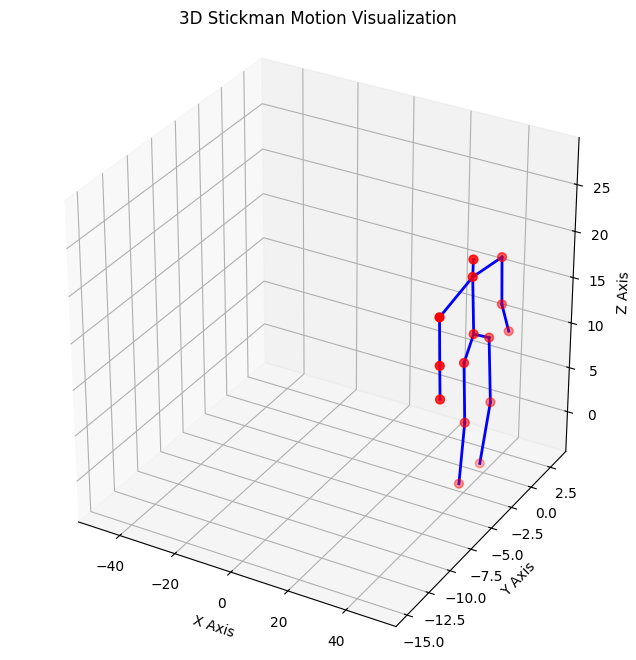

Saved: test_gifs/eda/normal_walk_136_23.gif


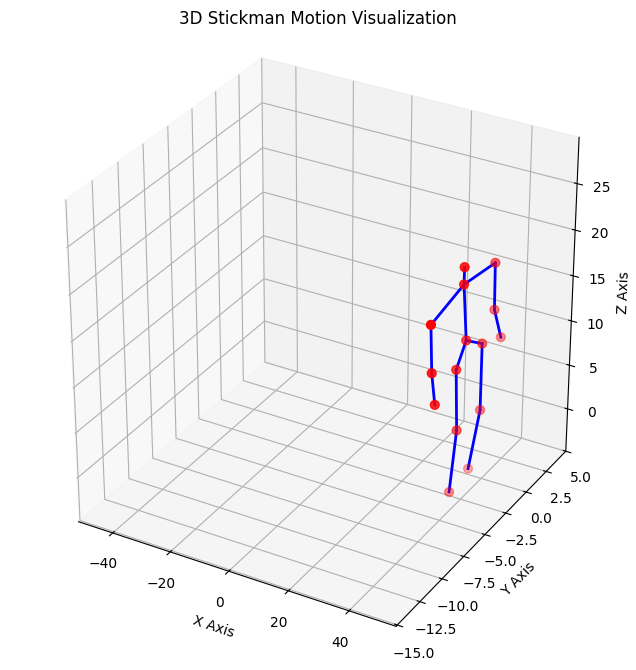

Saved: test_gifs/eda/normal_walk_136_21.gif


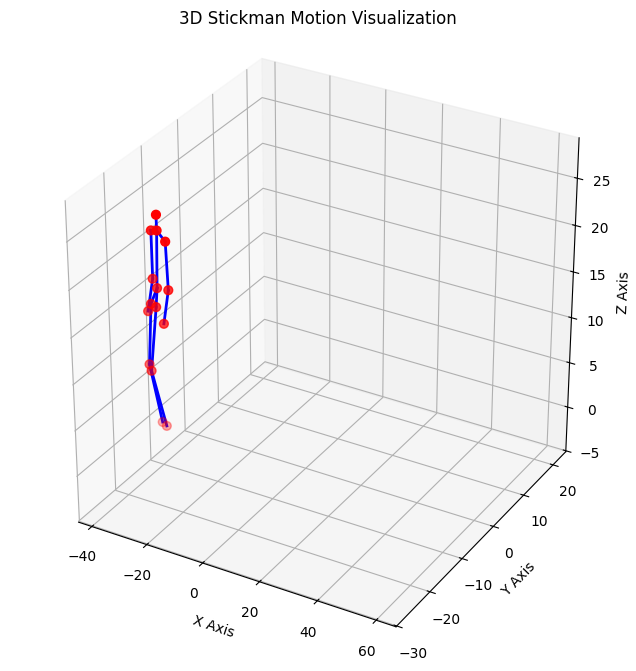

Saved: test_gifs/eda/normal_walk_137_29.gif


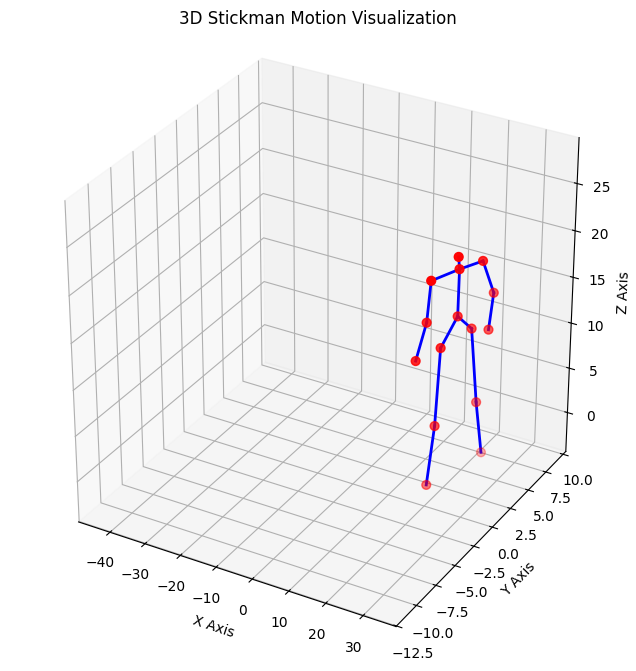

Saved: test_gifs/eda/walk_133_22.gif


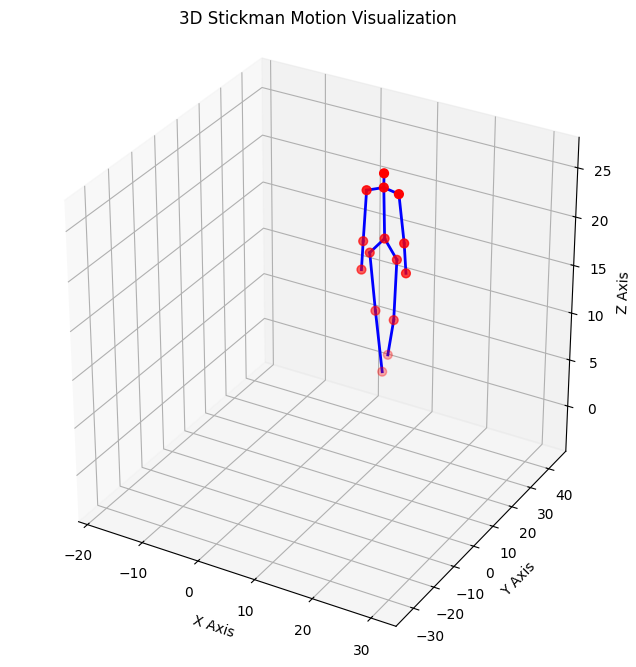

Saved: test_gifs/eda/walk_111_34.gif


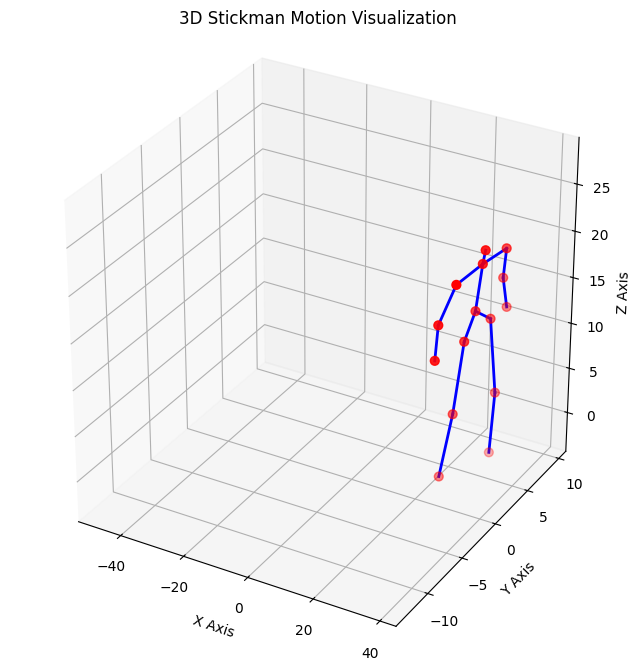

Saved: test_gifs/eda/walk_133_23.gif


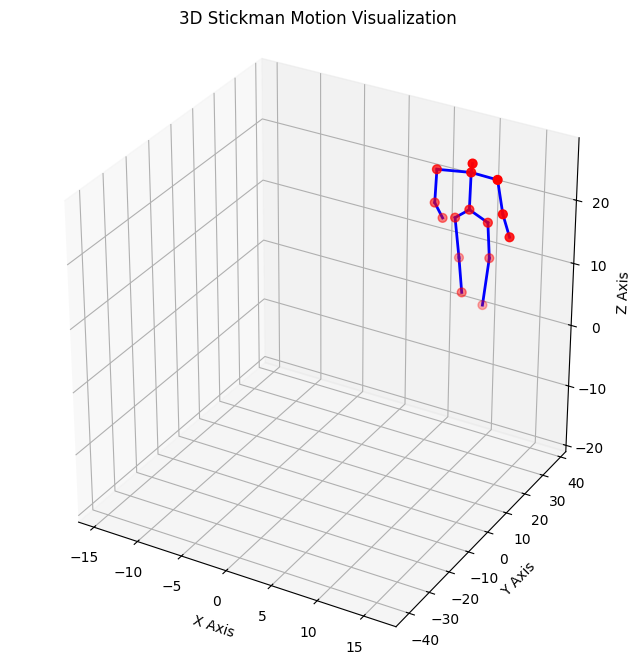

Saved: test_gifs/eda/brisk_walk_07_12.gif


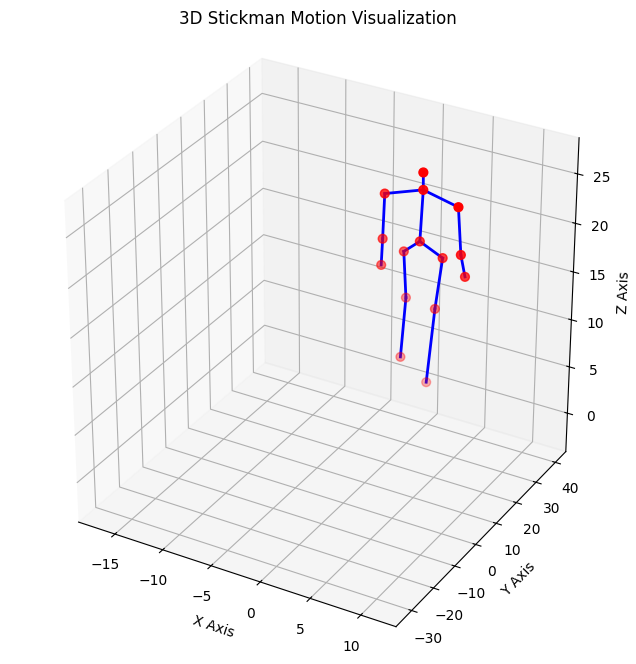

Saved: test_gifs/eda/slow_walk_37_01.gif


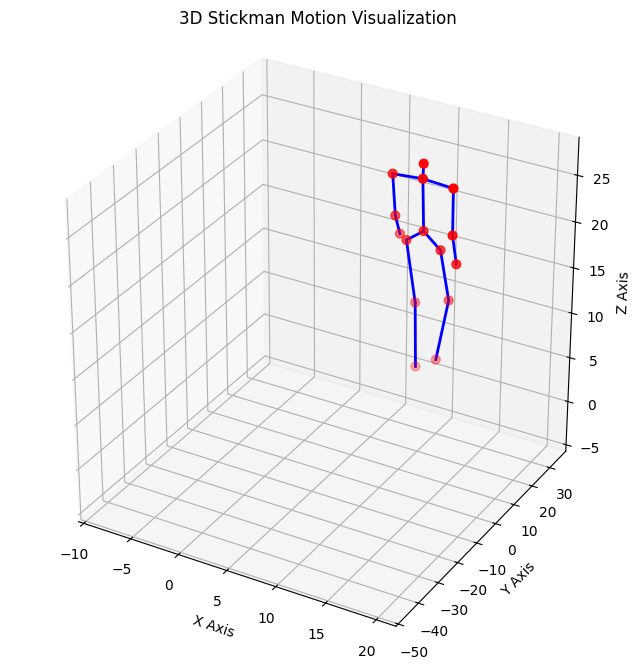

Saved: test_gifs/eda/slow_walk_08_04.gif


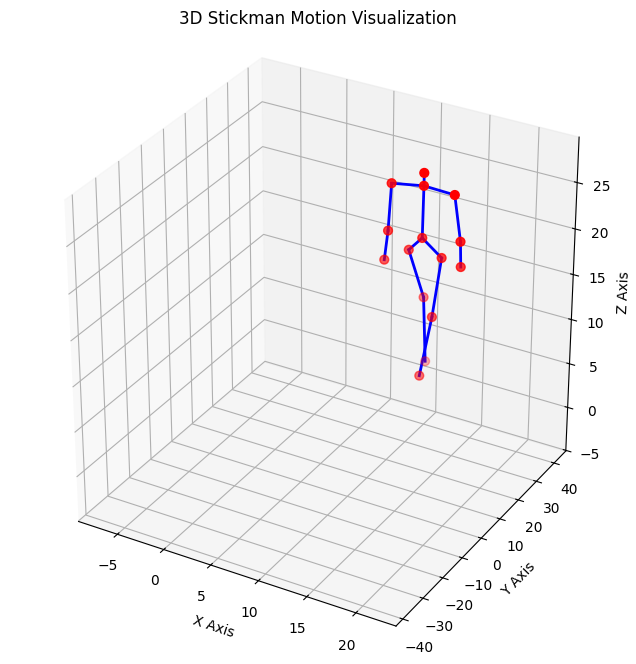

Saved: test_gifs/eda/slow_walk_07_05.gif


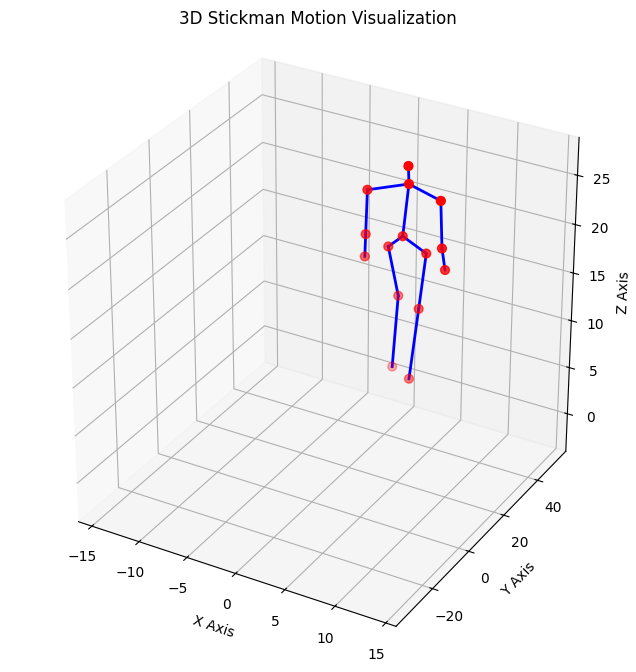

Saved: test_gifs/eda/walk_12_02.gif


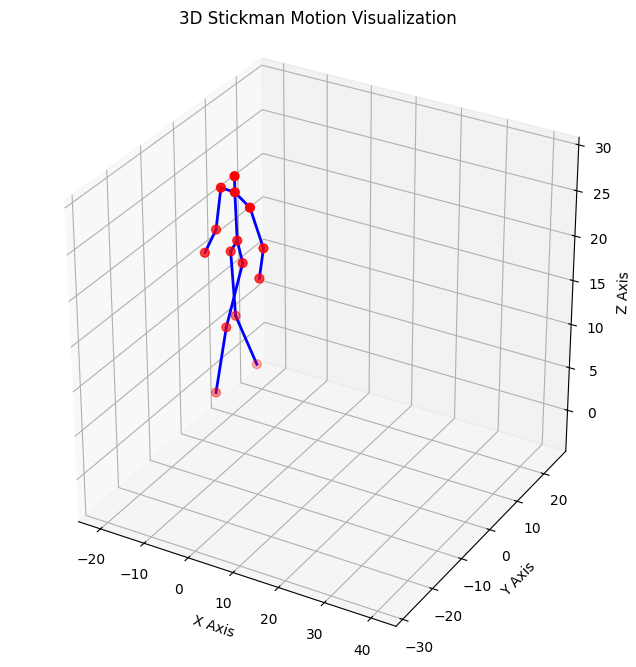

Saved: test_gifs/eda/walk_45_01.gif


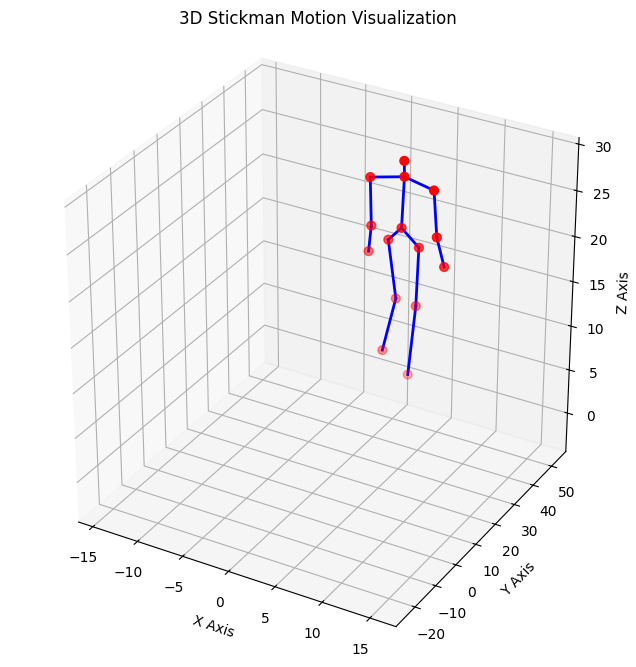

Saved: test_gifs/eda/walk_35_15.gif


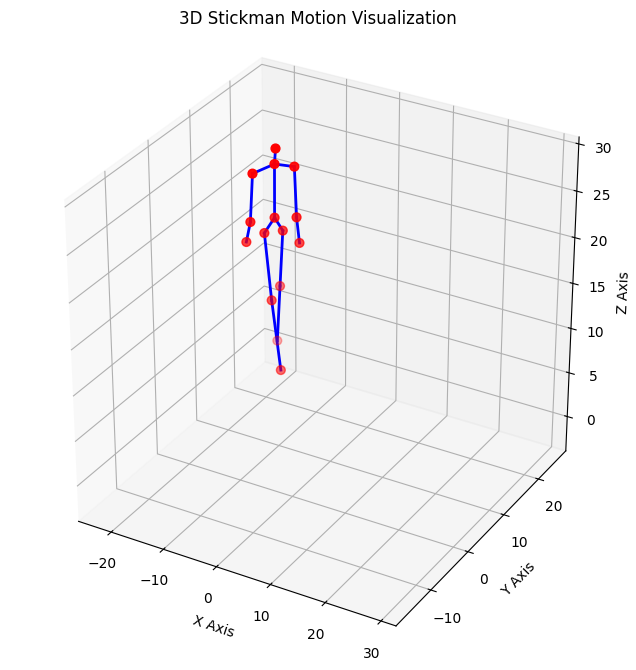

Saved: test_gifs/eda/walk_forward_69_02.gif


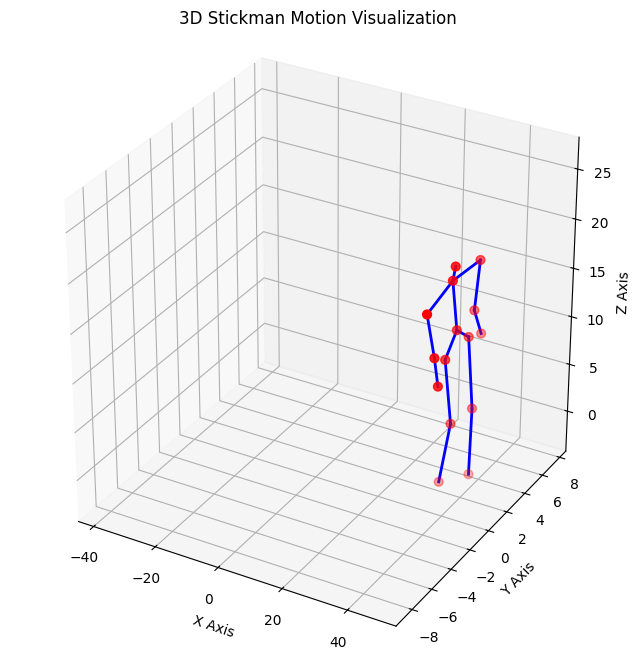

Saved: test_gifs/eda/walk_forward_81_02.gif


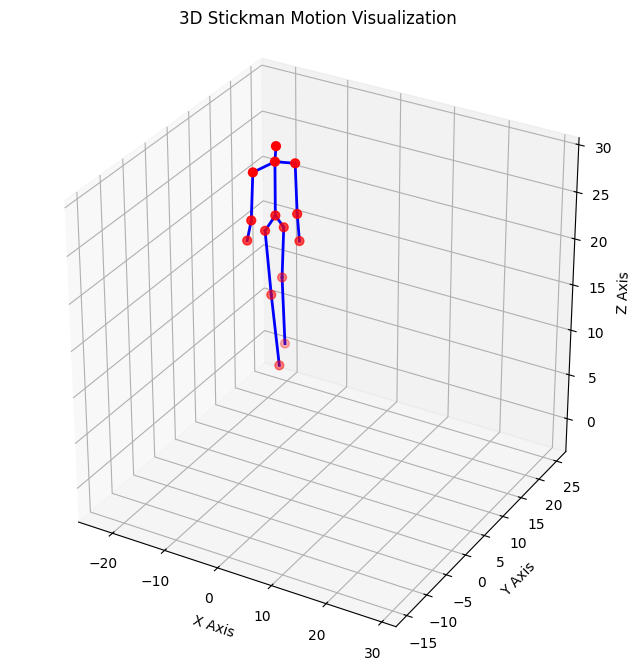

Saved: test_gifs/eda/walk_forward_69_01.gif


In [22]:
import os
import random
import sys
sys.path.append("..")

import importlib
import data_loader, utils
importlib.reload(data_loader)
importlib.reload(utils)

from data_loader import load_bvh_as_tensor
from utils import animate_skeleton_3d

OUTPUT_DIR = "test_gifs/eda"

os.makedirs(OUTPUT_DIR, exist_ok=True)

groups = clean_walk.groupby("description")

for desc, group in groups:
    paths = []
    for motion_id in group["motion_id"]:
        subject = motion_id.split("_")[0].zfill(3)
        path = f"../data/{subject}/{motion_id}.bvh"
        if os.path.exists(path):
            paths.append((motion_id, path))
    
    sampled = random.sample(paths, min(3, len(paths)))
    safe_desc = desc.lower().replace(" ", "_")
    
    for motion_id, path in sampled:
        tensor = load_bvh_as_tensor(path)
        filename = f"{OUTPUT_DIR}/{safe_desc}_{motion_id}.gif"
        anim = animate_skeleton_3d(tensor, output_filename=filename)
        print(f"Saved: {filename}")

In [23]:
import os
import shutil

OUTPUT_DIR = "selected_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for _, row in clean_walk.iterrows():
    motion_id = row["motion_id"]          # e.g. "07_04"
    description = row["description"]      # e.g. "slow walk"
    
    subject = motion_id.split("_")[0].zfill(3)
    src_path = f"../data/{subject}/{motion_id}.bvh"
    
    if not os.path.exists(src_path):
        print(f"Missing: {src_path}")
        continue
    
    desc_slug = description.strip().lower().replace(" ", "_")
    subject_part = motion_id.split("_")[0].zfill(3)
    take_part = motion_id.split("_")[1].zfill(3)
    new_name = f"{desc_slug}_{subject_part}_{take_part}.bvh"
    
    dst_path = os.path.join(OUTPUT_DIR, new_name)
    shutil.copy2(src_path, dst_path)
    print(f"Copied: {new_name}")

print(f"\nDone: {len(os.listdir(OUTPUT_DIR))} files in {OUTPUT_DIR}/")

Copied: walk_002_001.bvh
Copied: walk_002_002.bvh
Copied: walk_005_001.bvh
Copied: walk_006_001.bvh
Copied: walk_007_001.bvh
Copied: walk_007_002.bvh
Copied: walk_007_003.bvh
Copied: slow_walk_007_004.bvh
Copied: slow_walk_007_005.bvh
Copied: walk_007_006.bvh
Copied: walk_007_007.bvh
Copied: walk_007_008.bvh
Copied: walk_007_009.bvh
Copied: walk_007_010.bvh
Copied: walk_007_011.bvh
Copied: brisk_walk_007_012.bvh
Copied: walk_008_001.bvh
Copied: walk_008_002.bvh
Copied: walk_008_003.bvh
Copied: slow_walk_008_004.bvh
Copied: walk_008_006.bvh
Copied: walk_008_008.bvh
Copied: walk_008_009.bvh
Copied: walk_008_010.bvh
Copied: walk_010_004.bvh
Copied: walk_012_001.bvh
Copied: walk_012_002.bvh
Copied: walk_012_003.bvh
Copied: walk_016_015.bvh
Copied: walk_016_016.bvh
Copied: walk_016_021.bvh
Copied: walk_016_022.bvh
Copied: walk_016_031.bvh
Copied: walk_016_032.bvh
Copied: walk_016_047.bvh
Copied: walk_016_058.bvh
Copied: walk_026_001.bvh
Copied: walk_027_001.bvh
Copied: walk_029_001.bvh
Copi